## Online retail data

### RFM Customer Segmentation
#### Overview
This notebook focuses on creating and exploring RFM (Recency, Frequency, Monetary) features and performing customer segmentation to understand behavior and value. It includes feature derivation, distribution and correlation analysis, skewness handling, RFM scoring, segment classification, and interpretation of segment characteristics to generate actionable insights.

#### Objective
To derive and analyze RFM metrics, classify customers into meaningful segments, and provide insights for targeted engagement and value optimization.

#### Activities Covered
- RFM Feature Creation & Exploration – Build RFM metrics, check distributions, correlations, and correct skewness.
- Customer Segmentation Analysis – Score, combine, classify, and evaluate customer segments.
- Insight Generation & Recommendations – Identify high-value, at-risk, and growth-potential customers.
- Data Export for Tableau – Save segmented data for visualization and storytelling.

In [1]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### RFM Feature Creation and Exploration
#### Objective
To create and explore RFM features, assess customer behavior patterns, and prepare the dataset for segmentation and targeted business insights.

We examine:
1. **Data Sanity Check** – To confirm successful data loading, dataset structure, and variable availability before analysis.
2. **RFM Feature Engineering** – To derive Recency, Frequency, and Monetary metrics for customer-level analysis and segmentation.
3. **RFM Distribution Analysis** – To assess the spread and skewness of RFM variables and identify customer value concentration patterns.
4. **RFM Relationship Analysis (Heatmap)** – To examine correlations between RFM features and understand underlying customer behavior patterns.
5. **Skewness Correction (Log Transformation)** – To reduce skewness in Frequency and Monetary variables, improving scaling for segmentation

#### Key findings
1. **Dataset Integrity** – The dataset loaded successfully with the expected structure and data types, confirming readiness for analysis and ensuring reliable aggregation for downstream RFM feature construction.
2. **RFM Feature Construction** – Recency, Frequency, and Monetary features were successfully derived at the customer level, enabling consolidation of transactional data into meaningful behavioral metrics for segmentation.
3. **RFM Distribution Analysis** – The distributions of Recency, Frequency, and Monetary are strongly right-skewed, with most customers exhibiting low purchase frequency and modest spending, while a small subset demonstrates significantly higher engagement and expenditure. This indicates the presence of a limited group of high-value customers alongside a majority of low-activity customers.
4. **Log-Transformed RFM Distribution Analysis** – Log transformation substantially improves the distribution of Frequency and Monetary by compressing extreme values and reducing skewness, resulting in a more balanced spread of customer behavior. This confirms that high-frequency and high-spending customers are the primary drivers of skewness in the dataset.
5. **RFM Relationship Analysis (Correlation Heatmap)** – Frequency and Monetary display a moderately strong positive relationship, indicating that higher purchase frequency generally translates into greater overall spending. Recency, however, shows only weak negative relationships with both Frequency and Monetary, suggesting that while recently active customers tend to be slightly more engaged, recency alone is not a strong predictor of customer value, reinforcing the need to evaluate all three RFM dimensions jointly.
6. **Skewness Adjustment Justification** – Due to the pronounced right-skewness in Frequency and Monetary, log transformation was applied to reduce the influence of extreme values and improve score distribution, while Recency was retained in its original scale as its interpretation remains meaningful and quantile-based scoring adequately accounts for its distribution.

**Status**
RFM features created, log transformation applied to Frequency and Monetary, and the data is now ready for customer segmentation.

In [2]:
#Load data
df = pd.read_csv('../data/data_processed/cleaned_online_retail.csv', parse_dates=['InvoiceDate'])

#Inspect data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  int64         
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 27.0+ MB


In [3]:
# ii) Compute RFM features
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({'InvoiceDate':lambda x:(analysis_date - x.max()).days,
                                    'InvoiceNo':'nunique',
                                    'TotalPrice':'sum'})
rfm.columns=['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,124.80
12347.0,2,7,4185.20
12348.0,75,4,1530.03
12349.0,19,1,1443.50
12350.0,310,1,309.35


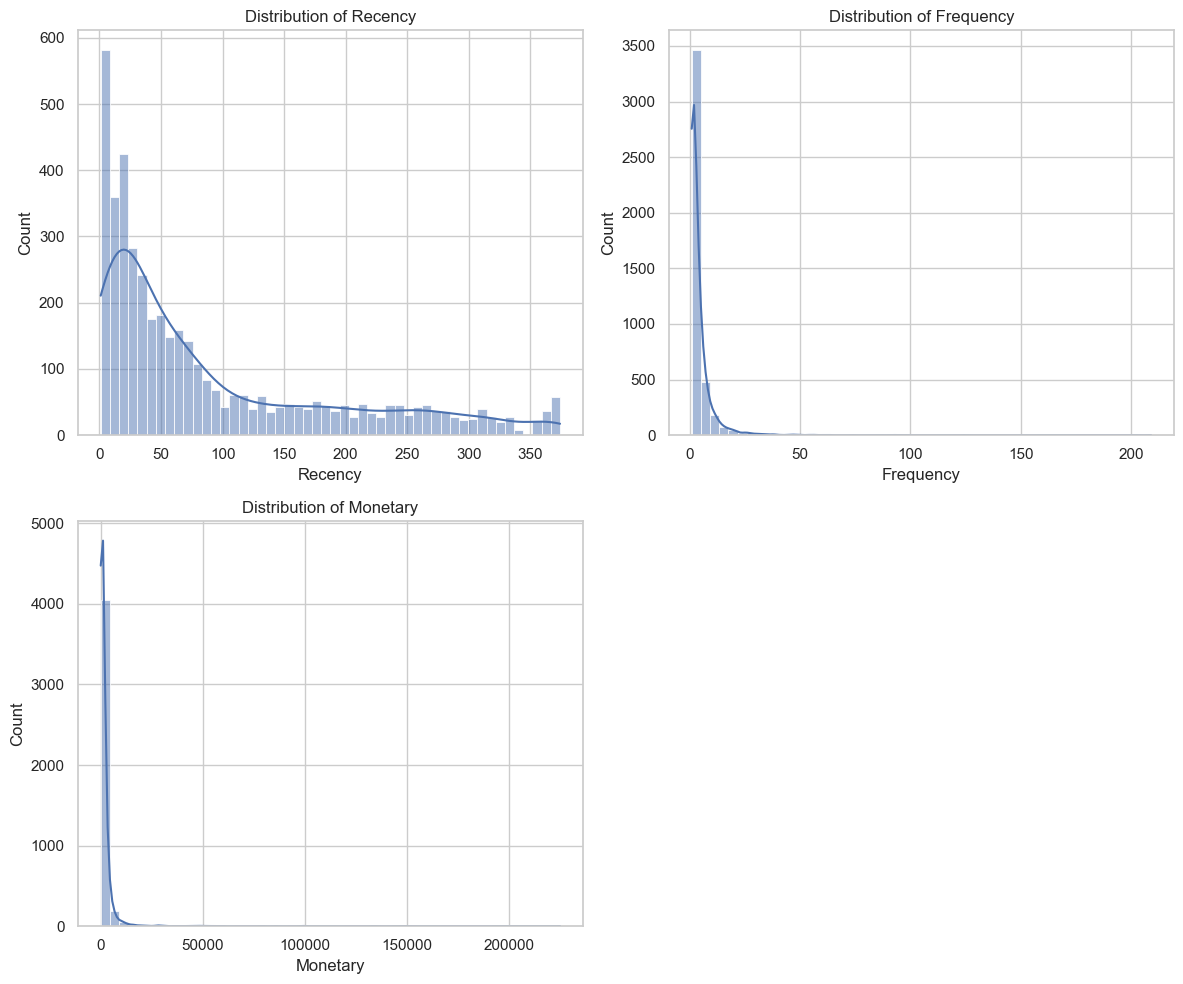

In [7]:
# iii) Check distribution of RFM features
rfm_features = ['Recency','Frequency','Monetary']
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,10))
for i, col in enumerate (rfm_features,1):
    plt.subplot(2,2,i)
    sns.histplot(data=rfm, x=col, bins=50, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(f'rfm_features_hist.png')
plt.show()

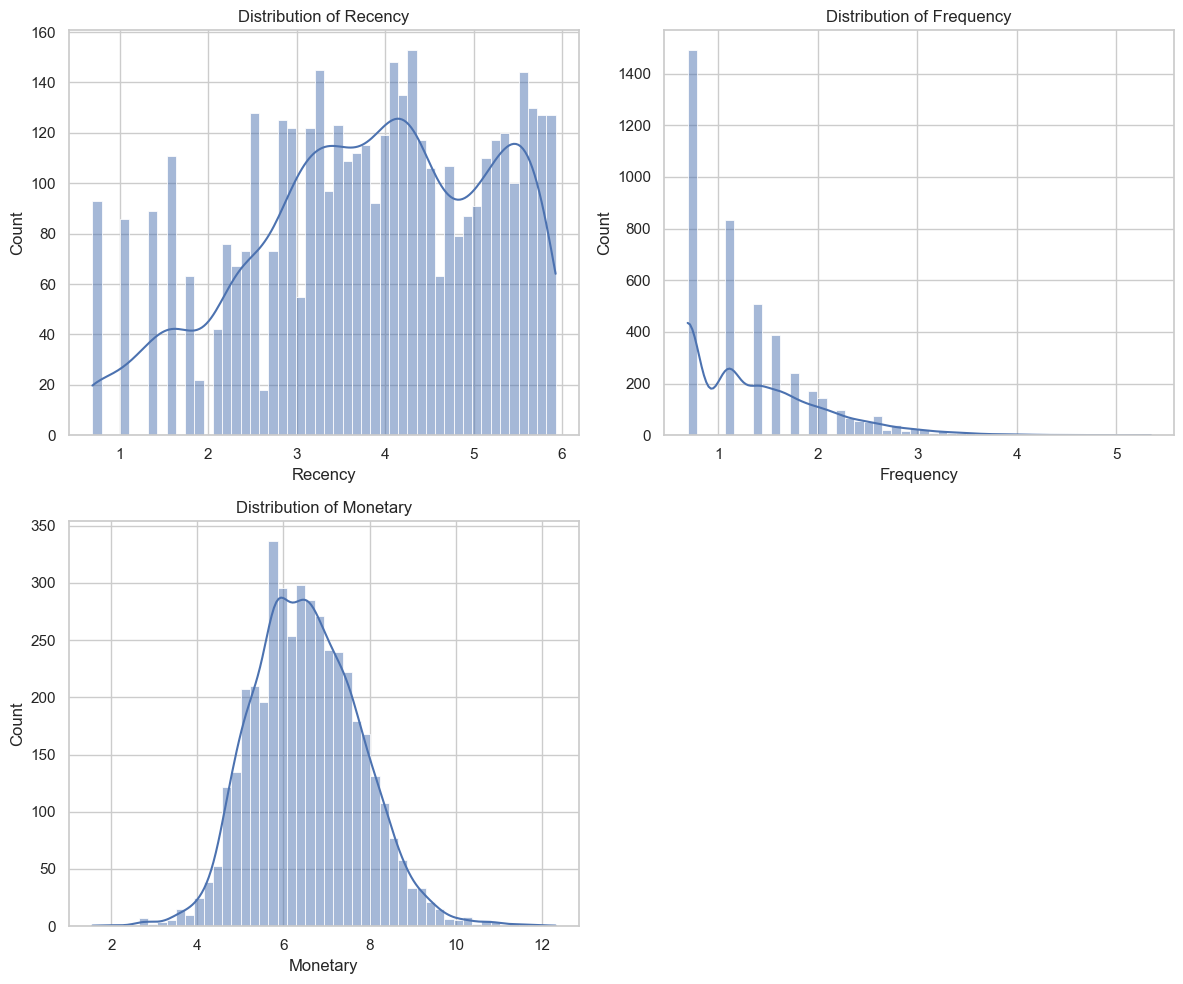

In [8]:
# iii) Visualize the distribution of log_transfomed rfm features
log_transformed=np.log1p(rfm[['Recency','Frequency','Monetary']])
sns.set_theme(style = 'whitegrid')
plt.figure(figsize=(12,10))
for i, col in enumerate (log_transformed.columns,1):
    plt.subplot(2,2,i)
    sns.histplot(data=log_transformed, x=col, bins=50, kde=True,)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(f'log_transfromed_rfm_hist.png')
plt.show()

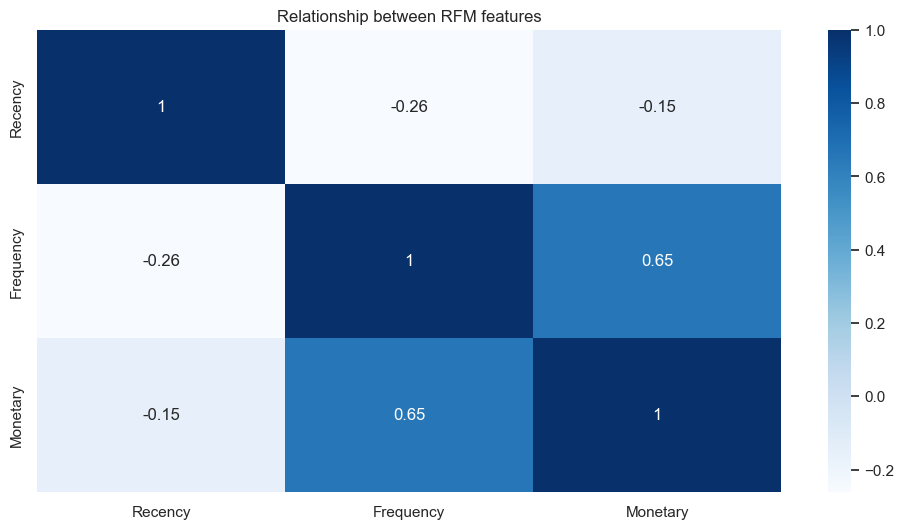

In [45]:
# Check the relationship between rfm features
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,6))
sns.heatmap(rfm[['Recency','Frequency','Monetary']].corr(),annot=True,cmap='Blues')
plt.title(f'Relationship between RFM features')
plt.savefig(f'relationship_between_rfm.png')
plt.show()

In [14]:
]# iv) Handle skewness
rfm['log_Monetary']=np.log1p(rfm['Monetary'])
rfm['log_Frequency'] = np.log1p(rfm['Frequency'])

### Customer Segmentation Analysis
#### Objective
To segment customers by RFM, analyze their behavior and revenue, and uncover actionable insights for engagement and value.

We Examine:
1. **RFM Scoring** – To assign quantile-based scores to Recency, Frequency, and Monetary variables, enabling standardized customer ranking.
2. **RFM Score Combination** – To concatenate individual RFM scores into a single composite score for segment identification.
3. **Customer Segmentation (Rule-Based)** – To classify customers into meaningful groups based on RFM score patterns using defined business rules.
4. **Segment Distribution Analysis** – To evaluate the composition of the customer base across segments and identify dominant groups.
5. **Revenue by Segment Analysis** – To determine revenue contribution by each segment and identify high-value customer groups.
6. **Behavior Profile Analysis** – To interpret segment characteristics by comparing average Recency, Frequency, and Monetary values.

#### Key Findings
1. **RFM Scoring and Combination** – Customers were assigned quantile-based RFM scores (1–4) for Recency, Frequency, and Monetary metrics, which were then combined into composite scores to clearly rank customer behavior and enable effective segment grouping.
2. **Customer Segmentation** – Customers were classified into 6 distinct segments based on RFM score patterns, creating meaningful groups such as Champions, Loyal Customers, and At Risk segments for targeted analysis.
3. **Segment Distribution Analysis** – The customer base is heavily concentrated in At Risk Loyal and Loyal Customers segments, while high-value segments like Champions represent a smaller proportion, indicating a broad base of low-to-moderate engagement customers.
4. **Revenue by Segment Analysis** – Revenue is highly concentrated among Champions and Loyal Customers, with Champions contributing the largest share despite their smaller size, highlighting a strong imbalance in value distribution across segments.
5. **Customer Behavior Profile (RFM Analysis)** – Champions exhibit very low recency and the highest frequency and monetary values, confirming them as highly engaged and high-value customers, while At Risk Loyal customers show very high recency with low frequency and spending, indicating previously active but currently disengaged customers; other segments display moderate patterns reflecting transitional customer states.

#### Business Insights
1. **Revenue is heavily dependent on a small group of high-value customers** – A relatively small segment (Champions) contributes a disproportionate share of total revenue, making customer retention and experience management for this group critical to overall business stability.
2. **A large share of customers show declining engagement despite past value** – The dominance of the At Risk Loyal segment indicates that many previously active customers are no longer purchasing frequently, highlighting a significant risk of revenue erosion if re-engagement strategies are not implemented.
3. **Customer value is driven more by behavior than timing** – Weak relationships between Recency and both Frequency and Monetary confirm that recent activity alone does not define customer worth, emphasizing the importance of sustained purchasing behavior over one-time or recent transactions.
4. **There is a clear pipeline for developing future high-value customers** – The presence of Potential Loyalists and New Customers shows that customer value evolves over time, creating an opportunity to intentionally move customers toward higher-value segments through targeted engagement.
5. **Customer base is skewed toward low-to-moderate engagement** – With most customers clustered in lower-frequency and lower-spending segments, overall growth depends more on increasing customer activity and spend than on acquiring new customers alone.

**Status**
The cleaned dataset and RFM segmentation outputs are saved as CSV files, ready for Tableau dashboards to drive insights through visual storytelling and strategic analysis.

🔹 1. Business Recommendations (Per Segment)

Champions – Retain through loyalty programs, exclusive offers, and personalized engagement, as they drive the highest revenue and show strong purchase behavior.

Loyal Customers – Upsell and cross-sell to increase their monetary value, while maintaining engagement to prevent churn into lower segments.

Potential Loyalists – Nurture through targeted promotions and follow-ups to increase purchase frequency and transition them into loyal or high-value customers.

New Customers – Focus on onboarding and early engagement strategies such as welcome offers to encourage repeat purchases and build long-term relationships.

At Risk Loyal – Re-engage using targeted campaigns, discounts, or reminders, as they show past value but declining activity.

Lost Customers – Apply selective win-back strategies where cost-effective, but deprioritize compared to higher-potential segments due to minimal contribution.

In [16]:
# i) Create RFM scores
rfm['R_Score'] = pd.qcut(rfm['Recency'],4,labels = [4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['log_Frequency'].rank(method='first'),4,labels = [1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['log_Monetary'],4,labels = [1,2,3,4])

# ii) Combine RFM scores
rfm['RFM_Score']= (rfm['R_Score'].astype('str') +
                   rfm['F_Score'].astype('str') + 
                   rfm['M_Score'].astype('str'))
rfm.head()

,Recency,Frequency,Monetary,R_Score,log_Monetary,log_Frequency,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,,
12346.0,326,1,124.80,1,4.834693,0.693147,1,1,111
12347.0,2,7,4185.20,4,8.339549,2.079442,4,4,444
12348.0,75,4,1530.03,2,7.333696,1.609438,3,3,233
12349.0,19,1,1443.50,3,7.275519,0.693147,1,3,313
12350.0,310,1,309.35,1,5.737701,0.693147,1,2,112


In [18]:
# iii) Segment customers
def segment_customer(row):
    if row['R_Score'] == 4 and row['F_Score'] == 4 and row['M_Score'] == 4:
        return 'Champions'
    elif row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] == 4 and row['F_Score'] <= 2:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 3:
        return 'At Risk Loyal'
    elif row['R_Score'] == 1:
        return 'Lost Customer'
    else:
        return 'Potential Loyalists'
rfm['Segment'] = rfm.apply(segment_customer,axis=1)
rfm[['RFM_Score','Segment']].head()

,RFM_Score,Segment
CustomerID,,
12346.0,111,At Risk Loyal
12347.0,444,Champions
12348.0,233,Loyal Customers
12349.0,313,Potential Loyalists
12350.0,112,At Risk Loyal


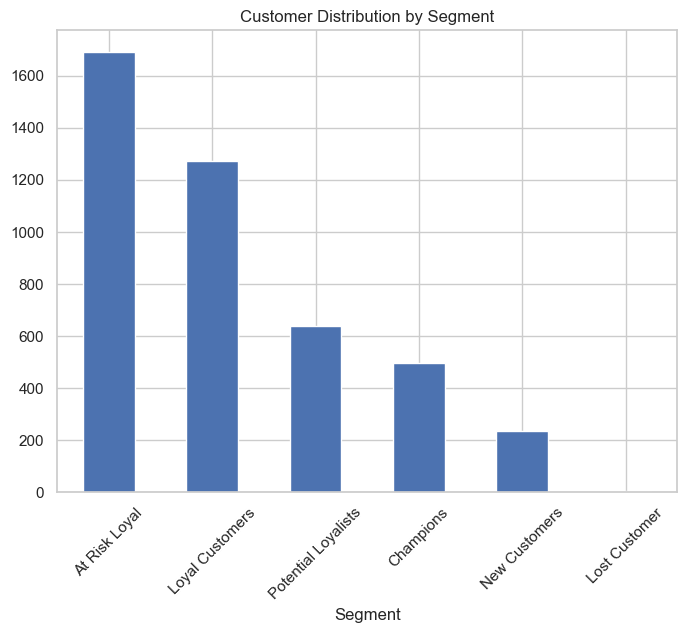

In [31]:
# iv) Check the distribution segments
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,6))
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Customer Distribution by Segment')
plt.xticks(rotation=45)
plt.savefig(f'customer_distribution_by_segment.png')
plt.show() 

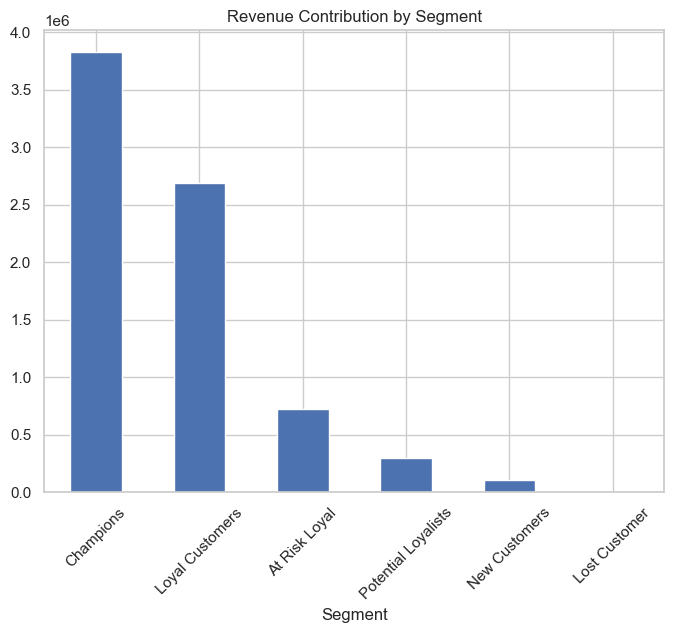

In [37]:
# v) Visualize Revenue by segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,6))
segment_revenue.plot(kind='bar')
plt.title('Revenue Contribution by Segment')
plt.xticks(rotation=45)
plt.savefig(f'revenue_contribution_by_segment.png')
plt.show() 

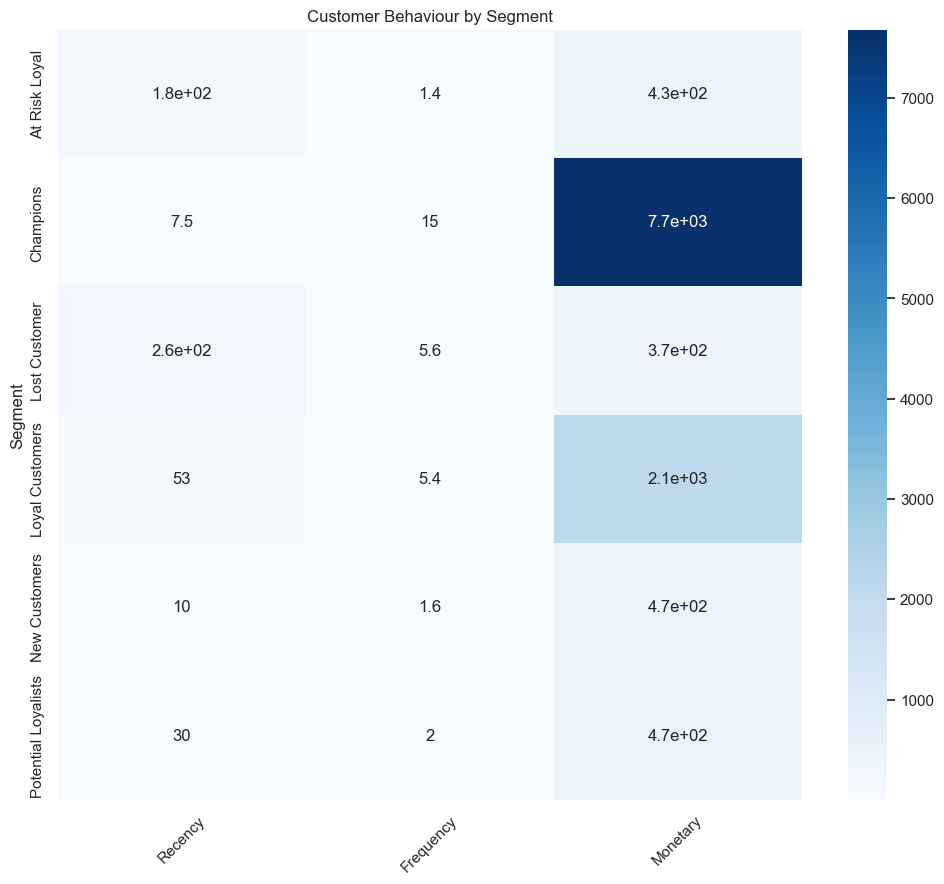

In [46]:
# vi) Visualize behavior profile
segment_profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
sns.set_theme(style='whitegrid')
plt.figure(figsize=(12,10))
sns.heatmap(segment_profile,annot=True, cmap='Blues')
plt.title('Customer Behaviour by Segment')
plt.xticks(rotation=45)
plt.savefig(f'customer_behavior_by_segment.png')
plt.show()

In [47]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Recency        4338 non-null   int64   
 1   Frequency      4338 non-null   int64   
 2   Monetary       4338 non-null   float64 
 3   R_Score        4338 non-null   category
 4   log_Monetary   4338 non-null   float64 
 5   log_Frequency  4338 non-null   float64 
 6   F_Score        4338 non-null   category
 7   M_Score        4338 non-null   category
 8   RFM_Score      4338 non-null   object  
 9   Segment        4338 non-null   object  
dtypes: category(3), float64(3), int64(2), object(2)
memory usage: 284.4+ KB


In [48]:
# vii) Save data to csv for tableau export
# a) convert rfm scores to intergers
rfm['R_Score']=rfm['R_Score'].astype(int)
rfm['F_Score']=rfm['F_Score'].astype(int)
rfm['M_Score']=rfm['M_Score'].astype(int)

# b) reset index
rfm = rfm.reset_index()

# c) save to data_processed folder
rfm.to_csv('../data/data_processed/rfm_table.csv')